<a href="https://colab.research.google.com/github/sidharth2733mba25fin-ops/COLLAB-FILES/blob/main/Lab_1_2_Bias_Detection_Loan_Approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1–2: Bias Detection in AI-Based Loan Approval Systems

**MBA Finance Lab | Ethical Foundations of Artificial Intelligence**

This Google Colab notebook helps students understand how bias can appear in AI-based loan approval systems using a **synthetic dataset**.

## Learning Objectives

By the end of this lab, students will be able to:

- Create a synthetic loan approval dataset.
- Understand how sensitive attributes such as gender, region, employment type, or credit history length can affect model outcomes.
- Train a basic Machine Learning model for loan approval prediction.
- Detect bias using approval rates across different customer groups.
- Calculate fairness metrics such as **Disparate Impact Ratio** and **Statistical Parity Difference**.
- Interpret why a technically accurate model may still be ethically problematic.

## Important Note

This dataset is fully synthetic. It is created only for classroom learning and does not represent any real bank, NBFC, fintech company, or real customer data.


## Cell 1: Install and Import Required Libraries

This cell imports the Python libraries required for data creation, visualization, model training, and fairness analysis.


In [ ]:
# Import required libraries
# pandas: used for handling tabular data
# numpy: used for numerical operations and random data generation
# matplotlib and seaborn: used for charts and visualizations
# sklearn: used for machine learning model training and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set display options so that students can see more columns clearly
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

# Set a random seed so results remain same every time notebook is run
np.random.seed(42)


## Cell 2: Create Synthetic Loan Applicant Dataset

In this cell, we create a synthetic dataset that resembles a simplified loan approval dataset.

The dataset includes both financial and demographic-style variables:

- `income`: Monthly income of applicant
- `credit_score`: Creditworthiness score
- `debt_to_income_ratio`: Existing debt burden compared to income
- `employment_type`: Salaried or self-employed
- `region`: Metro, Tier-2, or Rural
- `gender`: Male or Female
- `credit_history_years`: Number of years of formal credit history

We will intentionally create mild structural bias so students can detect it later.


In [ ]:
# Number of applicants in the synthetic dataset
n = 3000

# Create demographic and financial variables
# These are simulated values, not real customer records.

gender = np.random.choice(['Male', 'Female'], size=n, p=[0.58, 0.42])
region = np.random.choice(['Metro', 'Tier-2', 'Rural'], size=n, p=[0.45, 0.35, 0.20])
employment_type = np.random.choice(['Salaried', 'Self-Employed'], size=n, p=[0.68, 0.32])

# Income distribution is generated differently for employment type
# Salaried applicants are given more stable income values
# Self-employed applicants are given wider variation to mimic real business/cash-flow variation
income = []
for emp in employment_type:
    if emp == 'Salaried':
        income.append(np.random.normal(loc=65000, scale=18000))
    else:
        income.append(np.random.normal(loc=72000, scale=32000))

income = np.array(income)
income = np.clip(income, 15000, 250000)  # Prevent unrealistic negative or extremely low income values

# Credit score usually ranges between 300 and 900 in many credit scoring systems
credit_score = np.random.normal(loc=700, scale=80, size=n)
credit_score = np.clip(credit_score, 300, 900)

# Debt-to-income ratio: lower is generally better
# This variable represents how much of applicant income is already committed to debts

debt_to_income_ratio = np.random.beta(a=2, b=5, size=n)

# Credit history years: many first-time borrowers have short credit history
credit_history_years = np.random.exponential(scale=4, size=n)
credit_history_years = np.clip(credit_history_years, 0, 20)

# Create the dataframe
loan_df = pd.DataFrame({
    'gender': gender,
    'region': region,
    'employment_type': employment_type,
    'income': income.round(0),
    'credit_score': credit_score.round(0),
    'debt_to_income_ratio': debt_to_income_ratio.round(2),
    'credit_history_years': credit_history_years.round(1)
})

# Display first five rows
loan_df.head()


,gender,region,employment_type,income,credit_score,debt_to_income_ratio,credit_history_years
0,Male,Tier-2,Salaried,65955.0,762.0,0.07,6.0
1,Female,Tier-2,Salaried,80575.0,820.0,0.47,4.5
2,Female,Metro,Self-Employed,56740.0,665.0,0.58,2.6
3,Female,Tier-2,Salaried,95188.0,609.0,0.29,19.2
4,Male,Tier-2,Salaried,38711.0,503.0,0.20,2.1


## Cell 3: Create a Biased Loan Approval Rule

This is the most important teaching cell.

We create a synthetic loan approval target variable called `loan_approved`.

The approval logic uses genuine financial variables such as:

- Income
- Credit score
- Debt-to-income ratio
- Credit history

But we also introduce structural bias by applying penalties to certain groups:

- Self-employed applicants receive a penalty because their income is more irregular.
- Rural applicants receive a penalty because location may act as a risk proxy.
- Female applicants receive a small penalty to demonstrate how gender bias can enter silently.

This does not mean these groups are actually riskier. It only demonstrates how biased historical decisions can become encoded in data.


In [ ]:
# Create a base approval score using financial variables
# Higher income, higher credit score, lower debt ratio, and longer credit history should improve approval chance.

approval_score = (
    0.000012 * loan_df['income'] +
    0.006 * loan_df['credit_score'] -
    2.5 * loan_df['debt_to_income_ratio'] +
    0.08 * loan_df['credit_history_years']
)

# Introduce synthetic bias penalties
# These penalties are intentionally added for classroom demonstration.
# In real systems, these patterns may come from historical bias or proxy variables.

approval_score -= np.where(loan_df['employment_type'] == 'Self-Employed', 0.35, 0)
approval_score -= np.where(loan_df['region'] == 'Rural', 0.30, 0)
approval_score -= np.where(loan_df['gender'] == 'Female', 0.18, 0)

# Add small random noise to make data more realistic
approval_score += np.random.normal(0, 0.35, size=n)

# Convert score into probability using sigmoid function
# Sigmoid converts any numeric score into a value between 0 and 1
approval_probability = 1 / (1 + np.exp(-approval_score + 4.5))

# Create final approval decision
# If probability is greater than random threshold, loan is approved = 1, otherwise rejected = 0
loan_df['loan_approved'] = (approval_probability > np.random.rand(n)).astype(int)

# Display first few rows with target variable
loan_df.head()


,gender,region,employment_type,income,credit_score,debt_to_income_ratio,credit_history_years,loan_approved
0,Male,Tier-2,Salaried,65955.0,762.0,0.07,6.0,1
1,Female,Tier-2,Salaried,80575.0,820.0,0.47,4.5,1
2,Female,Metro,Self-Employed,56740.0,665.0,0.58,2.6,0
3,Female,Tier-2,Salaried,95188.0,609.0,0.29,19.2,1
4,Male,Tier-2,Salaried,38711.0,503.0,0.20,2.1,0


## Cell 4: Understand Dataset Shape and Basic Information

This cell helps students inspect the dataset before any analysis.

Always begin a data science project by checking:

- Number of rows and columns
- Data types
- Missing values
- Sample records


In [ ]:
# Check shape of the dataset
print('Dataset shape:', loan_df.shape)

# Check column data types and missing values
print('\nDataset information:')
loan_df.info()

# Check missing values in each column
print('\nMissing values per column:')
print(loan_df.isnull().sum())

Dataset shape: (3000, 8)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                3000 non-null   object 
 1   region                3000 non-null   object 
 2   employment_type       3000 non-null   object 
 3   income                3000 non-null   float64
 4   credit_score          3000 non-null   float64
 5   debt_to_income_ratio  3000 non-null   float64
 6   credit_history_years  3000 non-null   float64
 7   loan_approved         3000 non-null   int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 187.6+ KB

Missing values per column:
gender                  0
region                  0
employment_type         0
income                  0
credit_score            0
debt_to_income_ratio    0
credit_history_years    0
loan_approved           0
dtype: int64


## Cell 5: Summary Statistics for Numeric Variables

This cell shows descriptive statistics for numeric variables such as income, credit score, debt-to-income ratio, and credit history.

Students should observe:

- Average income
- Minimum and maximum credit score
- Average debt burden
- Spread of credit history


In [ ]:
# Display summary statistics for numeric columns
loan_df.describe()


,income,credit_score,debt_to_income_ratio,credit_history_years,loan_approved
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,67543.513667,699.287000,0.284733,4.021300,0.463667
std,22934.615735,78.735454,0.156261,3.938748,0.498761
min,15000.000000,430.000000,0.000000,0.000000,0.000000
25%,52567.000000,647.000000,0.160000,1.100000,0.000000
50%,66642.000000,699.000000,0.270000,2.800000,0.000000
75%,81051.750000,752.000000,0.380000,5.600000,1.000000
max,180076.000000,900.000000,0.830000,20.000000,1.000000


## Cell 6: Overall Loan Approval Rate

Before checking bias, we first calculate the overall approval rate.

This gives a baseline idea of how many applicants were approved in total.


In [ ]:
# Overall loan approval rate
approval_rate = loan_df['loan_approved'].mean()

print(f'Overall loan approval rate: {approval_rate:.2%}')


Overall loan approval rate: 46.37%


## Cell 7: Approval Rate by Gender

This cell checks whether approval rates differ by gender.

A large difference may indicate bias or may require deeper investigation.


   gender  loan_approved  approval_rate_percent
0  Female       0.443925              44.392523
1    Male       0.478438              47.843823


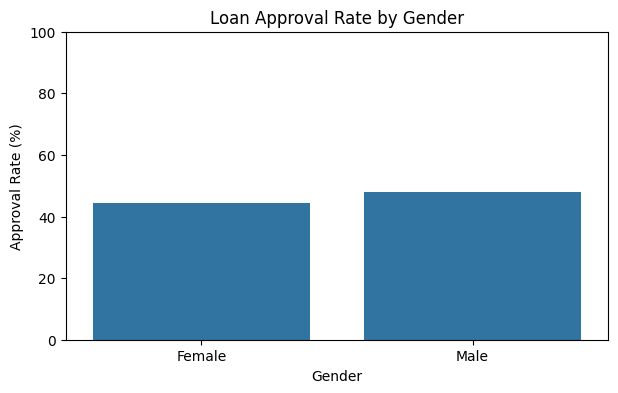

In [ ]:
# Calculate approval rate by gender
gender_approval = loan_df.groupby('gender')['loan_approved'].mean().reset_index()
gender_approval['approval_rate_percent'] = gender_approval['loan_approved'] * 100

print(gender_approval)

# Visualize approval rate by gender
plt.figure(figsize=(7, 4))
sns.barplot(data=gender_approval, x='gender', y='approval_rate_percent')
plt.title('Loan Approval Rate by Gender')
plt.ylabel('Approval Rate (%)')
plt.xlabel('Gender')
plt.ylim(0, 100)
plt.show()


## Cell 8: Approval Rate by Region

This cell checks whether applicants from Metro, Tier-2, and Rural regions receive different approval rates.

This is important because region can become a proxy for income class, infrastructure access, digital access, or historical repayment patterns.


   region  loan_approved  approval_rate_percent
0   Metro       0.467337              46.733668
1   Rural       0.407783              40.778342
2  Tier-2       0.491142              49.114173


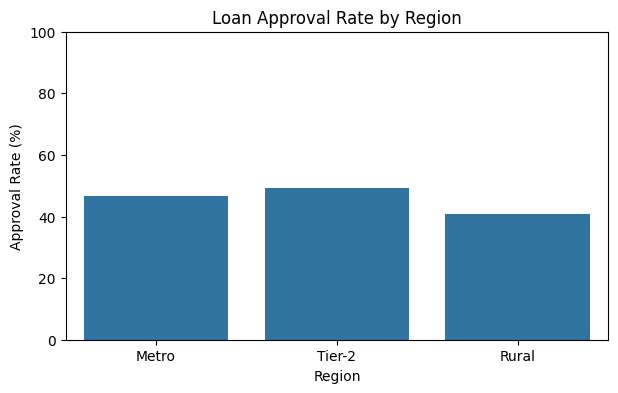

In [ ]:
# Calculate approval rate by region
region_approval = loan_df.groupby('region')['loan_approved'].mean().reset_index()
region_approval['approval_rate_percent'] = region_approval['loan_approved'] * 100

print(region_approval)

# Visualize approval rate by region
plt.figure(figsize=(7, 4))
sns.barplot(data=region_approval, x='region', y='approval_rate_percent', order=['Metro', 'Tier-2', 'Rural'])
plt.title('Loan Approval Rate by Region')
plt.ylabel('Approval Rate (%)')
plt.xlabel('Region')
plt.ylim(0, 100)
plt.show()


## Cell 9: Approval Rate by Employment Type

This cell checks whether salaried and self-employed applicants are treated differently.

This is highly relevant for MBA Finance because many small business owners have irregular cash flows but may still be creditworthy.


  employment_type  loan_approved  approval_rate_percent
0        Salaried       0.477112              47.711185
1   Self-Employed       0.431328              43.132804


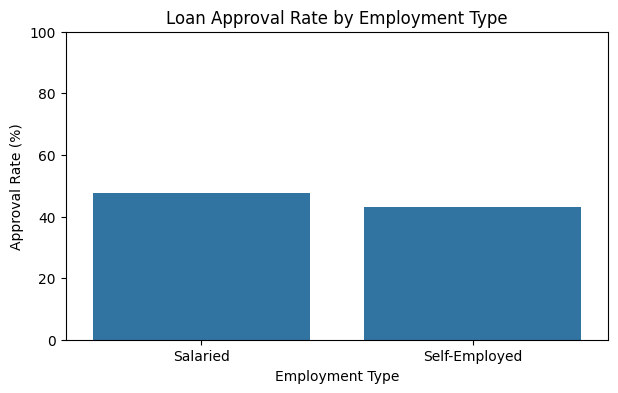

In [ ]:
# Calculate approval rate by employment type
employment_approval = loan_df.groupby('employment_type')['loan_approved'].mean().reset_index()
employment_approval['approval_rate_percent'] = employment_approval['loan_approved'] * 100

print(employment_approval)

# Visualize approval rate by employment type
plt.figure(figsize=(7, 4))
sns.barplot(data=employment_approval, x='employment_type', y='approval_rate_percent')
plt.title('Loan Approval Rate by Employment Type')
plt.ylabel('Approval Rate (%)')
plt.xlabel('Employment Type')
plt.ylim(0, 100)
plt.show()


## Cell 10: Intersectional Bias Analysis

Sometimes bias is not visible from one variable alone.

For example, rural female self-employed applicants may face a much lower approval rate than metro salaried male applicants.

This is called intersectional analysis because we examine multiple group identities together.


In [ ]:
# Calculate approval rate across gender, region, and employment type together
intersectional_approval = (
    loan_df
    .groupby(['gender', 'region', 'employment_type'])['loan_approved']
    .mean()
    .reset_index()
)

intersectional_approval['approval_rate_percent'] = (intersectional_approval['loan_approved'] * 100).round(2)

# Sort from lowest approval to highest approval
intersectional_approval = intersectional_approval.sort_values('approval_rate_percent')

intersectional_approval


,gender,region,employment_type,loan_approved,approval_rate_percent
3,Female,Rural,Self-Employed,0.337500,33.75
1,Female,Metro,Self-Employed,0.373134,37.31
8,Male,Rural,Salaried,0.405622,40.56
2,Female,Rural,Salaried,0.427746,42.77
5,Female,Tier-2,Self-Employed,0.429752,42.98
9,Male,Rural,Self-Employed,0.438202,43.82
7,Male,Metro,Self-Employed,0.451754,45.18
0,Female,Metro,Salaried,0.465558,46.56
10,Male,Tier-2,Salaried,0.487640,48.76
4,Female,Tier-2,Salaried,0.506944,50.69


## Cell 11: Visualize Intersectional Bias

This chart helps students clearly see which combined customer groups receive the lowest approval rates.


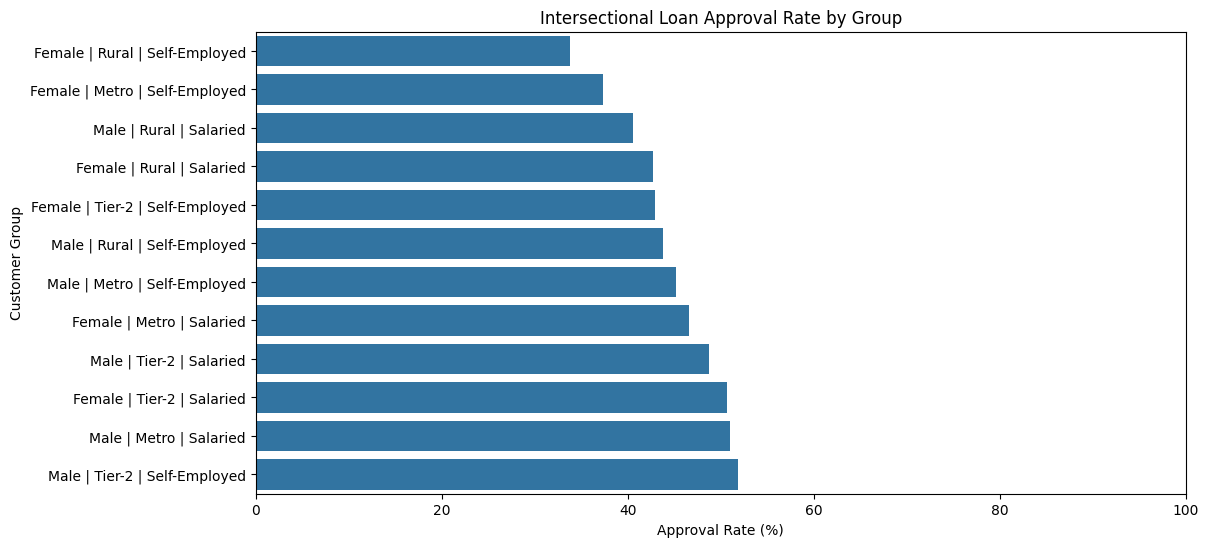

In [ ]:
# Create a combined group label for visualization
intersectional_approval['group'] = (
    intersectional_approval['gender'] + ' | ' +
    intersectional_approval['region'] + ' | ' +
    intersectional_approval['employment_type']
)

plt.figure(figsize=(12, 6))
sns.barplot(data=intersectional_approval, x='approval_rate_percent', y='group')
plt.title('Intersectional Loan Approval Rate by Group')
plt.xlabel('Approval Rate (%)')
plt.ylabel('Customer Group')
plt.xlim(0, 100)
plt.show()


## Cell 12: Create Features and Target for Model Training

Now we prepare data for machine learning.

`X` contains input features.

`y` contains the target variable: whether loan was approved or rejected.


In [ ]:
# Separate input features and target variable
X = loan_df.drop(columns=['loan_approved'])
y = loan_df['loan_approved']

# Identify categorical and numeric columns
categorical_features = ['gender', 'region', 'employment_type']
numeric_features = ['income', 'credit_score', 'debt_to_income_ratio', 'credit_history_years']

print('Categorical features:', categorical_features)
print('Numeric features:', numeric_features)


Categorical features: ['gender', 'region', 'employment_type']
Numeric features: ['income', 'credit_score', 'debt_to_income_ratio', 'credit_history_years']


## Cell 13: Train-Test Split

We divide the dataset into training and testing parts.

- Training data is used to teach the model.
- Testing data is used to evaluate model performance on unseen records.


In [ ]:
# Split data into train and test sets
# stratify=y ensures that approval/rejection ratio remains similar in train and test data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])


Training rows: 2250
Testing rows: 750


## Cell 14: Build Machine Learning Pipeline

Machine learning models cannot directly understand text categories such as Male, Female, Metro, or Rural.

Therefore, we use One-Hot Encoding to convert categorical columns into numeric format.

Then we train a Random Forest model.


In [ ]:
# OneHotEncoder converts categorical text variables into numeric dummy variables
# handle_unknown='ignore' prevents errors if test data has a new category

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# RandomForestClassifier is used because it can capture non-linear relationships
# It is commonly used for classification problems

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train the model
model.fit(X_train, y_train)

print('Model training completed successfully.')


Model training completed successfully.


## Cell 15: Evaluate Model Accuracy

This cell checks how well the model predicts loan approval decisions.

Important teaching point:

A model can have good accuracy and still be biased.


In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model accuracy: {accuracy:.2%}')

# Classification report gives precision, recall, and F1-score
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Model accuracy: 61.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.68      0.65       402
           1       0.59      0.53      0.56       348

    accuracy                           0.61       750
   macro avg       0.61      0.61      0.61       750
weighted avg       0.61      0.61      0.61       750



## Cell 16: Confusion Matrix

The confusion matrix helps us understand correct and incorrect predictions.

- True Negative: Correctly predicted rejection
- True Positive: Correctly predicted approval
- False Positive: Predicted approval but actually rejected
- False Negative: Predicted rejection but actually approved


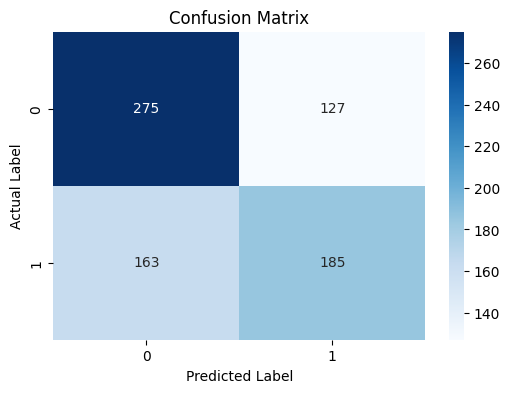

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Cell 17: Add Model Predictions Back to Test Data

We now combine model predictions with the original test dataset.

This allows us to check whether the trained model also shows biased outcomes.


In [ ]:
# Create a copy of test data for fairness analysis
results_df = X_test.copy()
results_df['actual_approval'] = y_test.values
results_df['predicted_approval'] = y_pred

results_df.head()


,gender,region,employment_type,income,credit_score,debt_to_income_ratio,credit_history_years,actual_approval,predicted_approval
218,Female,Tier-2,Salaried,83389.0,701.0,0.22,5.7,1,1
164,Male,Metro,Salaried,84021.0,742.0,0.26,3.1,0,1
2536,Female,Metro,Salaried,42914.0,513.0,0.09,3.4,0,0
2240,Female,Rural,Self-Employed,79209.0,671.0,0.16,13.0,1,1
1951,Male,Metro,Salaried,64865.0,614.0,0.18,4.6,0,0


## Cell 18: Model Prediction Approval Rate by Gender

This checks whether the model predicts different approval rates for different gender groups.


   gender  predicted_approval  predicted_approval_rate_percent
0  Female            0.392971                        39.297125
1    Male            0.432494                        43.249428


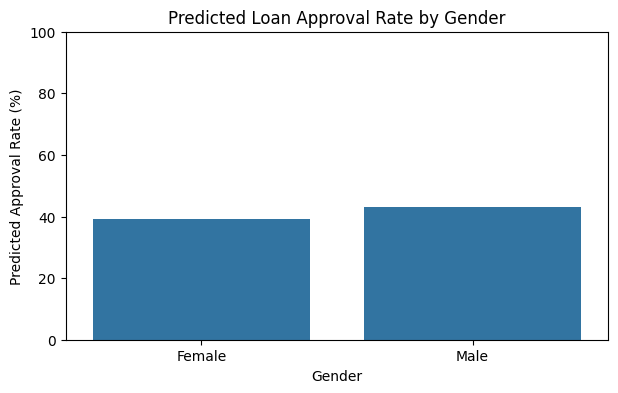

In [ ]:
# Predicted approval rate by gender
pred_gender_approval = results_df.groupby('gender')['predicted_approval'].mean().reset_index()
pred_gender_approval['predicted_approval_rate_percent'] = pred_gender_approval['predicted_approval'] * 100

print(pred_gender_approval)

plt.figure(figsize=(7, 4))
sns.barplot(data=pred_gender_approval, x='gender', y='predicted_approval_rate_percent')
plt.title('Predicted Loan Approval Rate by Gender')
plt.ylabel('Predicted Approval Rate (%)')
plt.xlabel('Gender')
plt.ylim(0, 100)
plt.show()


## Cell 19: Model Prediction Approval Rate by Region

This checks whether the trained model predicts different approval rates for Metro, Tier-2, and Rural applicants.


   region  predicted_approval  predicted_approval_rate_percent
0   Metro            0.434911                        43.491124
1   Rural            0.328571                        32.857143
2  Tier-2            0.437500                        43.750000


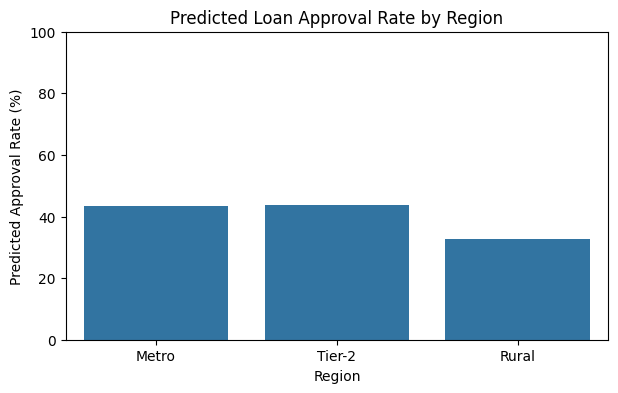

In [ ]:
# Predicted approval rate by region
pred_region_approval = results_df.groupby('region')['predicted_approval'].mean().reset_index()
pred_region_approval['predicted_approval_rate_percent'] = pred_region_approval['predicted_approval'] * 100

print(pred_region_approval)

plt.figure(figsize=(7, 4))
sns.barplot(data=pred_region_approval, x='region', y='predicted_approval_rate_percent', order=['Metro', 'Tier-2', 'Rural'])
plt.title('Predicted Loan Approval Rate by Region')
plt.ylabel('Predicted Approval Rate (%)')
plt.xlabel('Region')
plt.ylim(0, 100)
plt.show()


## Cell 20: Model Prediction Approval Rate by Employment Type

This checks whether salaried and self-employed applicants receive different predicted approval rates.


  employment_type  predicted_approval  predicted_approval_rate_percent
0        Salaried            0.446394                        44.639376
1   Self-Employed            0.350211                        35.021097


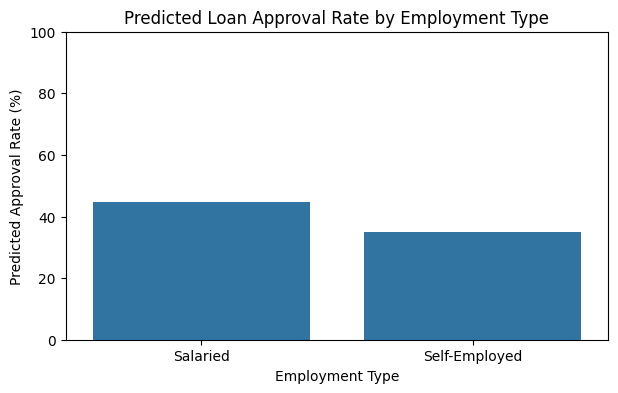

In [ ]:
# Predicted approval rate by employment type
pred_employment_approval = results_df.groupby('employment_type')['predicted_approval'].mean().reset_index()
pred_employment_approval['predicted_approval_rate_percent'] = pred_employment_approval['predicted_approval'] * 100

print(pred_employment_approval)

plt.figure(figsize=(7, 4))
sns.barplot(data=pred_employment_approval, x='employment_type', y='predicted_approval_rate_percent')
plt.title('Predicted Loan Approval Rate by Employment Type')
plt.ylabel('Predicted Approval Rate (%)')
plt.xlabel('Employment Type')
plt.ylim(0, 100)
plt.show()


## Cell 21: Fairness Metric 1 — Disparate Impact Ratio

Disparate Impact Ratio compares approval rate of an unprivileged group with approval rate of a privileged group.

Formula:

`Disparate Impact Ratio = Approval Rate of Unprivileged Group / Approval Rate of Privileged Group`

Common rule of thumb:

- Ratio close to 1 = more balanced
- Ratio below 0.80 may indicate potential adverse impact

Here we compare Female approval rate with Male approval rate.


In [ ]:
# Function to calculate disparate impact ratio

def disparate_impact_ratio(data, group_col, privileged_group, unprivileged_group, outcome_col):
    privileged_rate = data[data[group_col] == privileged_group][outcome_col].mean()
    unprivileged_rate = data[data[group_col] == unprivileged_group][outcome_col].mean()
    ratio = unprivileged_rate / privileged_rate
    return privileged_rate, unprivileged_rate, ratio

male_rate, female_rate, gender_di = disparate_impact_ratio(
    results_df,
    group_col='gender',
    privileged_group='Male',
    unprivileged_group='Female',
    outcome_col='predicted_approval'
)

print(f'Male predicted approval rate: {male_rate:.2%}')
print(f'Female predicted approval rate: {female_rate:.2%}')
print(f'Disparate Impact Ratio Female/Male: {gender_di:.2f}')

if gender_di < 0.80:
    print('Potential adverse impact detected based on the 80% rule.')
else:
    print('No strong adverse impact detected based on the 80% rule.')


Male predicted approval rate: 43.25%
Female predicted approval rate: 39.30%
Disparate Impact Ratio Female/Male: 0.91
No strong adverse impact detected based on the 80% rule.


## Cell 22: Fairness Metric 2 — Statistical Parity Difference

Statistical Parity Difference measures the absolute difference in approval rates between two groups.

Formula:

`Statistical Parity Difference = Unprivileged Approval Rate - Privileged Approval Rate`

Interpretation:

- Value close to 0 means more equal approval rates.
- Negative value means unprivileged group has lower approval rate.
- Positive value means unprivileged group has higher approval rate.


In [ ]:
# Calculate statistical parity difference for gender
statistical_parity_difference = female_rate - male_rate

print(f'Statistical Parity Difference Female - Male: {statistical_parity_difference:.2%}')

if statistical_parity_difference < 0:
    print('Female applicants have lower predicted approval rate than male applicants in this model.')
elif statistical_parity_difference > 0:
    print('Female applicants have higher predicted approval rate than male applicants in this model.')
else:
    print('Both groups have equal predicted approval rate in this model.')


Statistical Parity Difference Female - Male: -3.95%
Female applicants have lower predicted approval rate than male applicants in this model.


## Cell 23: Disparate Impact by Region

Now we compare Rural applicants with Metro applicants.

This helps students understand geographic bias in credit models.


In [ ]:
# Calculate disparate impact ratio for Rural vs Metro applicants
metro_rate, rural_rate, region_di = disparate_impact_ratio(
    results_df,
    group_col='region',
    privileged_group='Metro',
    unprivileged_group='Rural',
    outcome_col='predicted_approval'
)

print(f'Metro predicted approval rate: {metro_rate:.2%}')
print(f'Rural predicted approval rate: {rural_rate:.2%}')
print(f'Disparate Impact Ratio Rural/Metro: {region_di:.2f}')

if region_di < 0.80:
    print('Potential adverse impact detected for Rural applicants based on the 80% rule.')
else:
    print('No strong adverse impact detected for Rural applicants based on the 80% rule.')


Metro predicted approval rate: 43.49%
Rural predicted approval rate: 32.86%
Disparate Impact Ratio Rural/Metro: 0.76
Potential adverse impact detected for Rural applicants based on the 80% rule.


## Cell 24: Disparate Impact by Employment Type

Now we compare self-employed applicants with salaried applicants.

This is important because self-employed borrowers may have irregular income, but irregularity does not always mean poor repayment ability.


In [ ]:
# Calculate disparate impact ratio for Self-Employed vs Salaried applicants
salaried_rate, self_employed_rate, employment_di = disparate_impact_ratio(
    results_df,
    group_col='employment_type',
    privileged_group='Salaried',
    unprivileged_group='Self-Employed',
    outcome_col='predicted_approval'
)

print(f'Salaried predicted approval rate: {salaried_rate:.2%}')
print(f'Self-employed predicted approval rate: {self_employed_rate:.2%}')
print(f'Disparate Impact Ratio Self-Employed/Salaried: {employment_di:.2f}')

if employment_di < 0.80:
    print('Potential adverse impact detected for self-employed applicants based on the 80% rule.')
else:
    print('No strong adverse impact detected for self-employed applicants based on the 80% rule.')


Salaried predicted approval rate: 44.64%
Self-employed predicted approval rate: 35.02%
Disparate Impact Ratio Self-Employed/Salaried: 0.78
Potential adverse impact detected for self-employed applicants based on the 80% rule.


## Cell 25: Feature Importance Analysis

Feature importance shows which variables the model relies on most.

This is useful for detecting whether sensitive or proxy variables may be influencing decisions.


In [ ]:
# Extract feature names after one-hot encoding
encoded_feature_names = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_feature_names) + numeric_features

# Extract feature importance from Random Forest model
importances = model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

feature_importance_df


,feature,importance
8,credit_score,0.266078
7,income,0.224115
9,debt_to_income_ratio,0.208350
10,credit_history_years,0.202283
4,region_Tier-2,0.015458
0,gender_Female,0.014953
2,region_Metro,0.014856
3,region_Rural,0.014712
1,gender_Male,0.014484
6,employment_type_Self-Employed,0.012427


## Cell 26: Visualize Feature Importance

This chart helps students identify whether variables such as gender, region, or employment type are affecting model predictions.


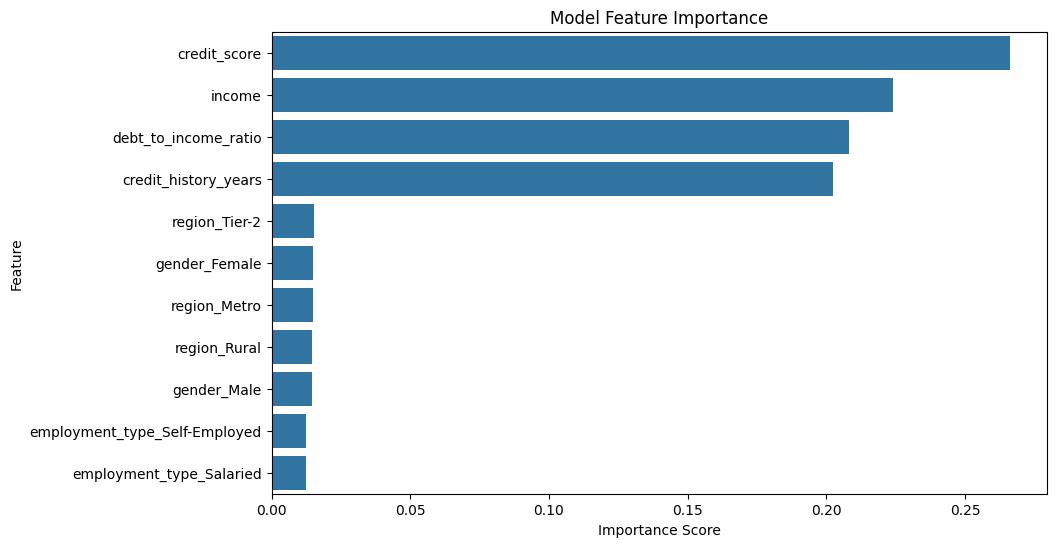

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature')
plt.title('Model Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


## Cell 27: Bias Mitigation Experiment — Remove Sensitive Variable Gender

One simple mitigation attempt is to remove a sensitive variable such as gender.

Important teaching point:

Removing gender does not always eliminate bias because other variables may act as proxies.


In [ ]:
# Create new dataset without gender
X_no_gender = loan_df.drop(columns=['loan_approved', 'gender'])
y_no_gender = loan_df['loan_approved']

categorical_features_no_gender = ['region', 'employment_type']
numeric_features_no_gender = ['income', 'credit_score', 'debt_to_income_ratio', 'credit_history_years']

X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(
    X_no_gender, y_no_gender, test_size=0.25, random_state=42, stratify=y_no_gender
)

preprocessor_ng = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_no_gender),
        ('num', 'passthrough', numeric_features_no_gender)
    ]
)

model_ng = Pipeline(steps=[
    ('preprocessor', preprocessor_ng),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

model_ng.fit(X_train_ng, y_train_ng)
y_pred_ng = model_ng.predict(X_test_ng)

print(f'Model accuracy without gender: {accuracy_score(y_test_ng, y_pred_ng):.2%}')


Model accuracy without gender: 61.60%


## Cell 28: Check Whether Removing Gender Changed Bias

We removed gender from the model input, but we still compare predictions using original gender values from the same test rows.

This demonstrates whether bias can remain through proxy variables.


   gender  predicted_approval_no_gender  approval_rate_percent
0  Female                      0.424920              42.492013
1    Male                      0.409611              40.961098


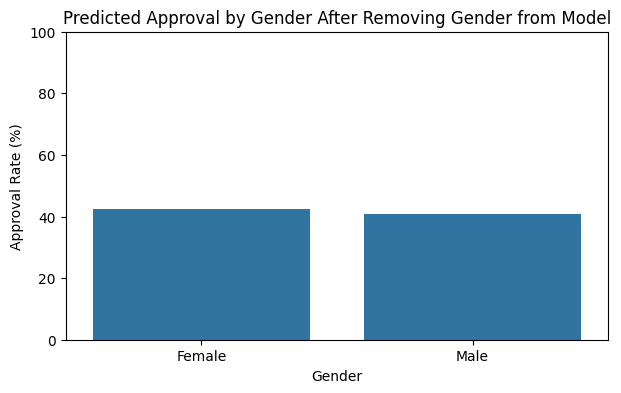

In [ ]:
# Reconnect gender from original dataset using test index
results_ng = X_test_ng.copy()
results_ng['gender'] = loan_df.loc[X_test_ng.index, 'gender']
results_ng['predicted_approval_no_gender'] = y_pred_ng

# Calculate predicted approval by gender after removing gender from model input
pred_gender_ng = results_ng.groupby('gender')['predicted_approval_no_gender'].mean().reset_index()
pred_gender_ng['approval_rate_percent'] = pred_gender_ng['predicted_approval_no_gender'] * 100

print(pred_gender_ng)

plt.figure(figsize=(7, 4))
sns.barplot(data=pred_gender_ng, x='gender', y='approval_rate_percent')
plt.title('Predicted Approval by Gender After Removing Gender from Model')
plt.ylabel('Approval Rate (%)')
plt.xlabel('Gender')
plt.ylim(0, 100)
plt.show()


## Cell 29: Create a Fairness Summary Table

This final table summarizes important fairness findings in one place.


In [ ]:
# Create summary table of fairness metrics
fairness_summary = pd.DataFrame({
    'Comparison': ['Female vs Male', 'Rural vs Metro', 'Self-Employed vs Salaried'],
    'Privileged Group Approval Rate': [male_rate, metro_rate, salaried_rate],
    'Unprivileged Group Approval Rate': [female_rate, rural_rate, self_employed_rate],
    'Disparate Impact Ratio': [gender_di, region_di, employment_di],
    'Statistical Parity Difference': [female_rate - male_rate, rural_rate - metro_rate, self_employed_rate - salaried_rate]
})

# Convert rates into percentage format for readability
fairness_summary['Privileged Group Approval Rate'] = (fairness_summary['Privileged Group Approval Rate'] * 100).round(2)
fairness_summary['Unprivileged Group Approval Rate'] = (fairness_summary['Unprivileged Group Approval Rate'] * 100).round(2)
fairness_summary['Disparate Impact Ratio'] = fairness_summary['Disparate Impact Ratio'].round(2)
fairness_summary['Statistical Parity Difference'] = (fairness_summary['Statistical Parity Difference'] * 100).round(2)

fairness_summary


,Comparison,Privileged Group Approval Rate,Unprivileged Group Approval Rate,Disparate Impact Ratio,Statistical Parity Difference
0,Female vs Male,43.25,39.30,0.91,-3.95
1,Rural vs Metro,43.49,32.86,0.76,-10.63
2,Self-Employed vs Salaried,44.64,35.02,0.78,-9.62


## Cell 30: Final Interpretation for Students

Use this cell to discuss the result in class.

Key discussion points:

- A model may show good accuracy but still treat groups differently.
- Bias can enter through historical data, proxy variables, and imbalanced sampling.
- Removing sensitive variables does not always remove bias.
- Finance managers must ask both performance and fairness questions.
- Responsible AI requires monitoring, explainability, and governance.


In [ ]:
# Print final interpretation notes for classroom discussion
print('CLASSROOM INTERPRETATION')
print('-' * 60)
print('1. Accuracy alone is not enough for financial AI systems.')
print('2. Approval rates should be compared across customer groups.')
print('3. Disparate Impact Ratio below 0.80 may suggest adverse impact.')
print('4. Bias can remain even after removing sensitive variables because proxy variables may exist.')
print('5. Ethical AI in finance requires fairness audits, explainability, human review, and continuous monitoring.')


CLASSROOM INTERPRETATION
------------------------------------------------------------
1. Accuracy alone is not enough for financial AI systems.
2. Approval rates should be compared across customer groups.
3. Disparate Impact Ratio below 0.80 may suggest adverse impact.
4. Bias can remain even after removing sensitive variables because proxy variables may exist.
5. Ethical AI in finance requires fairness audits, explainability, human review, and continuous monitoring.


# Lab Submission Questions

Students may answer the following questions after running the notebook:

1. What was the overall approval rate in the dataset?
2. Which group received the lowest approval rate?
3. Did the model show any potential adverse impact using the Disparate Impact Ratio?
4. Why can removing gender fail to remove bias completely?
5. Which feature appeared most important in the model?
6. How can a finance institution reduce bias in loan approval systems?
7. Why is fairness important from both ethical and business perspectives?
